In [80]:
import numpy as np
import matplotlib.pyplot as plt
import pickle
from pathlib import Path
from IPython.display import Audio
import IPython.display as ipd
from scipy.io import wavfile
import tempfile
import os
import librosa
import pandas as pd
import seaborn as sns
import h5py
import mne
from scipy.stats import zscore
from mne_bids import BIDSPath, read_raw_bids
from matplotlib_venn import venn2,venn2_circles
from tqdm import tqdm

In [81]:
cm = 1/2.54
plt.rcParams['svg.fonttype'] = 'none'

fontdict = dict(fontsize=7)
fontsize = 7

red = '#A9373B'
blue = '#2369BD'
orange = '#CC8963'
green = '#009944'

stg_color = '#20B2AA'
smc_color = '#6A5ACD'
insula_color = '#D4AF37'

reds = sns.light_palette(red, as_cmap=True)
blues = sns.light_palette(blue, as_cmap=True)
oranges = sns.light_palette(orange, as_cmap=True)
greens = sns.light_palette(green, as_cmap=True)

recon_dir = '/cwork/ns458/ECoG_Recon/'
mne.viz.set_3d_backend('notebook')                    

'notebook'

# Load parcellation

In [82]:
bids_root = '/cwork/ns458/BIDS-1.0_LexicalDecRepDelay/BIDS/'
# bids_root = '/cwork/ns458/BIDS-1.0_LexicalDecRepNoDelay/BIDS/'
# bids_root = '/cwork/ns458/BIDS-1.4_Phoneme_sequencing/BIDS/'
# '/cwork/ns458/BIDS-1.3_PictureNaming/BIDS/',
# '/cwork/ns458/BIDS-1.4_SentenceRep/BIDS/',


parc_paths = BIDSPath(
        root=os.path.join(bids_root, 'derivatives/parcellation'),
        datatype='bipolar',
        processing='3mm',
        suffix='aparc2009s',
        extension='.csv',
        check=False,
    ).match()

parc = pd.concat([pd.read_csv(parc_path) for parc_path in parc_paths], ignore_index=True)
    
parc.head()

,subject,name,x,y,z,center,label,fraction,2nd label,2nd fraction,3rd label,3rd fraction,roi,hemi
0,D0023,D0023_RASF1-2,0.015286,0.041071,-0.005071,ctx_rh_S_orbital_med-olfact,Intersection,0.308943,ctx_rh_G_rectus,0.235772,Right-Cerebral-White-Matter,0.186992,Intersection,R
1,D0023,D0023_RASF2-3,0.015857,0.041214,-0.001214,ctx_rh_S_orbital_med-olfact,ctx_rh_S_orbital_med-olfact,0.520325,Right-Cerebral-White-Matter,0.447154,Unknown,0.032520,OFCs,R
2,D0023,D0023_RASF3-4,0.016429,0.041357,0.002643,Right-Cerebral-White-Matter,Right-Cerebral-White-Matter,0.983740,ctx_rh_S_orbital_med-olfact,0.016260,NaN,0.000000,WM,R
3,D0023,D0023_RASF4-5,0.017000,0.041500,0.006500,Right-Cerebral-White-Matter,Right-Cerebral-White-Matter,1.000000,NaN,0.000000,NaN,0.000000,WM,R
4,D0023,D0023_RASF5-6,0.017643,0.041286,0.010214,Right-Cerebral-White-Matter,Right-Cerebral-White-Matter,1.000000,NaN,0.000000,NaN,0.000000,WM,R


In [83]:
# take the DMN node out
core_dmn_labels = [
    'ctx_lh_G_and_S_cingul-Mid-Post', 'ctx_rh_G_and_S_cingul-Mid-Post',  
    'ctx_lh_G_precuneus', 'ctx_rh_G_precuneus',                           
    'ctx_lh_G_pariet_inf-Angular', 'ctx_rh_G_pariet_inf-Angular',         
    'ctx_lh_G_front_sup-medial', 'ctx_rh_G_front_sup-medial',            
    'ctx_lh_Pole_temporal', 'ctx_rh_Pole_temporal'                        
]

parc = parc[parc.label.isin(core_dmn_labels)]
# rename "name" to channel
parc.rename(columns={'name': 'channel'}, inplace=True)
parc.roi.unique()

array(['CG', 'AG', 'TP', 'PCun'], dtype=object)

# Take data out

In [84]:
epos = []

for sub in tqdm(parc.subject.unique()):
        
    picks = parc[parc.subject==sub].channel.unique().tolist()
    
    pts = BIDSPath(
        root=os.path.join(bids_root, 'derivatives', 'epoch(bipolar)'),
        datatype='epoch(band)(zscore)',
        suffix='highgamma',
        subject=sub,
        extension='.h5',
        check=False
    )

    for pt in pts.match():
        dc_epo = mne.read_epochs(pt, verbose='error')
        # onset = dc_epo.events[:, 0] / 2048
        # dc_epo.metadata = pd.DataFrame({'onset': onset}, index=dc_epo.selection)
        dc_epo.pick(picks)
        df = dc_epo.to_data_frame(long_format=True, scalings={'seeg': 1}, verbose=False)
        # meta = dc_epo.metadata.reset_index(names='epoch')  # epoch == selection
        # df = df.merge(meta, on='epoch', how='left')

        # drop ch_type column
        df = df.drop(columns=['ch_type'])
        df['phase'] = pt.processing
        df['description'] = pt.description
        df['subject'] = sub
        df['remark'] = df['condition'].str.split('/').str[4:].str.join('/')
        df['condition'] = df['condition'].str.split('/').str[2:4].str.join('/')
        df['lexical'] = df['condition'].str.split('/').str[0]
        
        # Map lexical values: Word -> Yes, Non-Word -> No
        df['lexical'] = df['lexical'].map({'Word': 'Yes', 'Nonword': 'No'})
        
        epos.append(df)

# Concatenate across subjects (optional)
epos = pd.concat(epos, ignore_index=True)
epos.head()

100%|██████████| 23/23 [03:11<00:00,  8.34s/it]


,condition,epoch,time,channel,value,phase,description,subject,remark,lexical
0,Word/latin,2,-1.0,D0023_RPSF4-5,-0.929324,Delay,Decision,D0023,ERR_TASK/YN_REP,Yes
1,Word/latin,2,-1.0,D0023_RPSF5-6,-0.221441,Delay,Decision,D0023,ERR_TASK/YN_REP,Yes
2,Word/latin,2,-1.0,D0023_RPMF1-2,1.070099,Delay,Decision,D0023,ERR_TASK/YN_REP,Yes
3,Word/latin,2,-1.0,D0023_RPMF2-3,0.254799,Delay,Decision,D0023,ERR_TASK/YN_REP,Yes
4,Word/latin,2,-1.0,D0023_RPMF3-4,0.422597,Delay,Decision,D0023,ERR_TASK/YN_REP,Yes


In [85]:
# merge parc
epos_ =  epos.merge(parc[['channel', 'label','roi','hemi']], on='channel', how='left')
epos_.head()

,condition,epoch,time,channel,value,phase,description,subject,remark,lexical,label,roi,hemi
0,Word/latin,2,-1.0,D0023_RPSF4-5,-0.929324,Delay,Decision,D0023,ERR_TASK/YN_REP,Yes,ctx_rh_G_and_S_cingul-Mid-Post,CG,R
1,Word/latin,2,-1.0,D0023_RPSF5-6,-0.221441,Delay,Decision,D0023,ERR_TASK/YN_REP,Yes,ctx_rh_G_and_S_cingul-Mid-Post,CG,R
2,Word/latin,2,-1.0,D0023_RPMF1-2,1.070099,Delay,Decision,D0023,ERR_TASK/YN_REP,Yes,ctx_rh_G_and_S_cingul-Mid-Post,CG,R
3,Word/latin,2,-1.0,D0023_RPMF2-3,0.254799,Delay,Decision,D0023,ERR_TASK/YN_REP,Yes,ctx_rh_G_and_S_cingul-Mid-Post,CG,R
4,Word/latin,2,-1.0,D0023_RPMF3-4,0.422597,Delay,Decision,D0023,ERR_TASK/YN_REP,Yes,ctx_rh_G_and_S_cingul-Mid-Post,CG,R


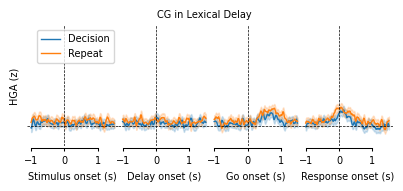

In [86]:
colors = [red, blue]
rois = ['CG']

subset = epos_[
    (epos_.roi.isin(rois))
    & (epos_.hemi=='L')
    # & (epos_.description=='Decision')
]

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=1, ncols=4, figsize=(12*cm, 4*cm),gridspec_kw={'width_ratios': [2.5, 2.5, 2.5, 2.5]})

plt.subplots_adjust(wspace=0)

for (ax, phase) in zip(fig.axes, ['Stimulus', 'Delay', 'Go', 'Response']):
    
    # only add the legend to the first axis
    legend = False if ax != fig.axes[0] else True
    
    line = sns.lineplot(
        data=subset[(subset.phase == phase)],
        x='time',
        y='value',
        hue='description',
        ax=ax,
        legend=legend,
        lw=1
    )
    
    ax.set_ylim(-0.2, 1)


for ax in fig.axes:
    ax.axvline(x=0, color='k', linestyle='--', linewidth=0.5)
    ax.axhline(y=0, color='k', linestyle='--', linewidth=0.5)
    
    ax.tick_params(labelsize=7, width=.75, length=2, which='both')
    plt.setp(ax.spines.values(), linewidth=.75)
    
    sns.despine(ax=ax, offset=1, trim=True)
    
    # Only add legend to the last axis if it has artists with labels
    if ax.get_legend() is not None:
        ax.legend(title='', fontsize=7)
    else:
        # Remove legend from other axes
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
    
    ax.set_yticklabels([])
    ax.set_yticks([])
    # remove y spine
    ax.spines['left'].set_visible(False)
    
    
ax1.set_xlabel('Stimulus onset (s)', fontsize=7)   
ax2.set_xlabel('Delay onset (s)', fontsize=7)   
ax3.set_xlabel('Go onset (s)', fontsize=7)   
ax4.set_xlabel('Response onset (s)', fontsize=7)   
ax1.set_ylabel('HGA (z)', fontsize=7)
ax2.set_ylabel('', fontsize=7)
ax3.set_ylabel('', fontsize=7)
ax4.set_ylabel('', fontsize=7)

plt.suptitle(rois[0] + ' in Lexical Delay', fontsize=7)
# plt.savefig(f'../img/fig4/fig4_{rois[0]}_condition_difference.svg', dpi=300, bbox_inches='tight')

plt.show()